In [107]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spikeinterface as si
import spikeinterface.extractors as se
import cmap

from tools.io import load_units_metadata, load_probe

data_path = Path(r"R:\Basic_Sciences\Phys\SenzaiLab\Elissa_Belluccini\Kilosort\Mouse10_20260210_795to2220")
data_path = data_path / 'ProbeA'
output_path = Path("D:/common_datasets/gamma")

fs = 30000

plt.style.use('dark_background')
heatmap = cmap.Colormap('seaborn:vlag').to_matplotlib()

In [106]:
units = load_units_metadata(data_path / 'kilosort')
probe = load_probe(data_path / 'kilosort')
probe

,x,depth,shank_ids,depth_rank
202,0.0,795.0,0,0
205,32.0,810.0,0,1
206,0.0,825.0,0,2
209,32.0,840.0,0,3
210,0.0,855.0,0,4
...,...,...,...,...
193,782.0,2160.0,3,91
194,750.0,2175.0,3,92
197,782.0,2190.0,3,93
198,750.0,2205.0,3,94


In [15]:
rec = si.load(str(data_path / 'concat'))
sorting = se.read_kilosort(data_path / 'kilosort').select_units(units['cluster_id'].values)
sorting

UnitsSelectionSorting: 306 units - 1 segments - 30.0kHz

In [ ]:
pp = si.create_sorting_analyzer(
    sorting=sorting,
    recording=rec,
    sparse=False,
    folder=output_path / 'postprocess',
    format='binary_folder',
    overwrite=False,
)

job_kwargs = dict(n_jobs=-1, chunk_duration="2s", progress_bar=True)

compute_dict = {
    'random_spikes': {'method': 'uniform', 'max_spikes_per_unit': 5000},
    'templates': {'operators': ["average", "std"]}
}

pp.compute(compute_dict, **job_kwargs)

estimate_templates_with_accumulator (workers: 24 processes spawn): 100%|██████████| 18197/18197 [25:11<00:00, 12.04it/s] 


In [37]:
template_ext = pp.get_extension('templates')

ms_before = template_ext.params['ms_before']
ms_after = template_ext.params['ms_after']
templates = template_ext.get_templates()

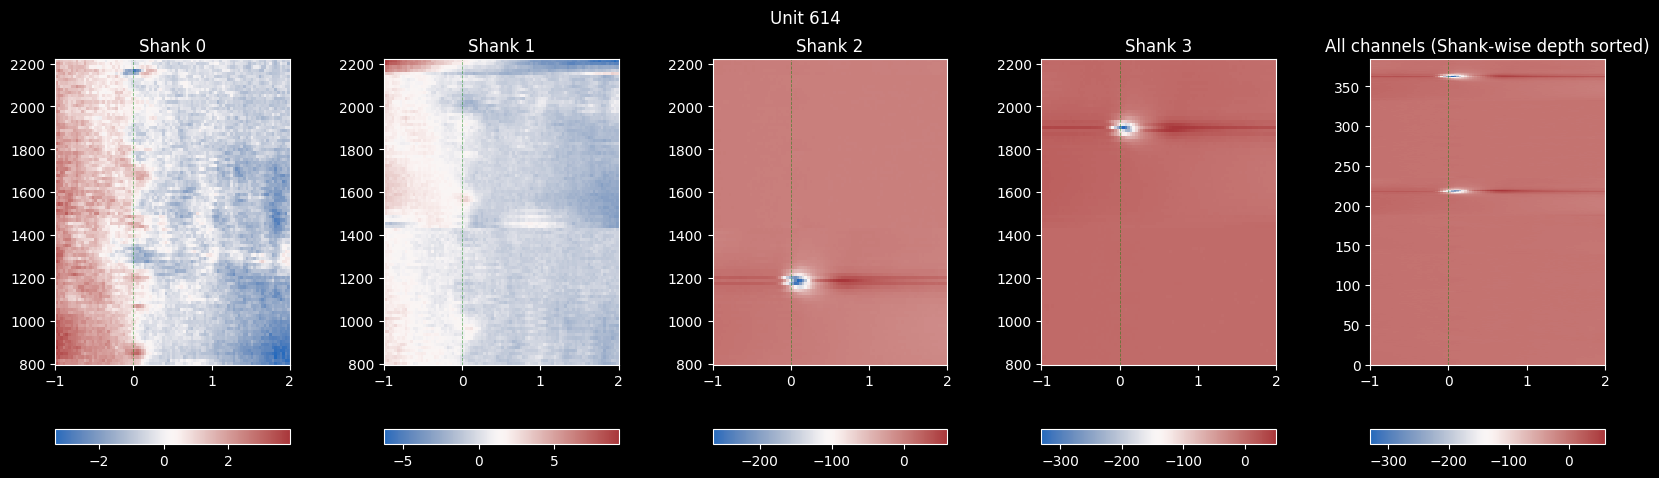

In [189]:
unit_idx = 614
idx = np.where(sorting.unit_ids == unit_idx)[0].item()
template = templates[idx].copy()
template = template - template.mean(axis=0)

fig, axs = plt.subplots(2, 5, figsize=(20, 5), sharex=False, sharey=False,
                        gridspec_kw={'height_ratios': [1, 0.05], 'wspace': 0.4, 'hspace': 0.4}
)
fig.suptitle(f'Unit {sorting.unit_ids[idx]}')
for i in range(4): # 4 shanks
    shank_mask = probe['shank_ids'] == i
    shank_sorted_idx = probe[shank_mask].index.values
    depths = probe[shank_mask]['depth'].values
    
    axs[0, i].set_title(f'Shank {i}')
    im = axs[0, i].imshow(
            template[:, shank_sorted_idx].T,
            aspect='auto',
            origin='lower',
            interpolation='none',
            cmap=heatmap,
            extent=[-ms_before, ms_after, depths[0], depths[-1]]
        )
    axs[0, i].axvline(0, color='green', linestyle='--', alpha=0.5, linewidth=0.6)
    fig.colorbar(im, cax=axs[1, i], orientation='horizontal')
    

axs[0, 4].set_title('All channels (Shank-wise depth sorted)')
im = axs[0, 4].imshow(template[:, probe.index.values].T, aspect='auto', origin='lower', interpolation='none', cmap=heatmap, extent=[-ms_before, ms_after, 0, 384])
axs[0, 4].axvline(0, color='green', linestyle='--', alpha=0.5, linewidth=0.6)
fig.colorbar(im, cax=axs[1, 4], orientation='horizontal')

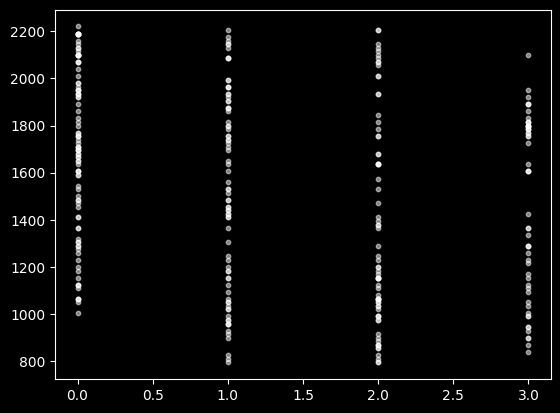

In [186]:
plt.scatter(units['shank_ids'], units['depth'], c='white', s=10, alpha=0.5)